# Inverse-Diagnostic Demo

Этот notebook является frontend к продуктовому pipeline `run_inverse_diagnostic_cycle(...)`.
Вся бизнес-логика (observation mapping, canonicalization, HMM decoding, recommendation) выполняется в Python-модуле `src/hidden_patterns_combat/app/inverse_diagnostic_cycle.py`.
Notebook только запускает pipeline и честно показывает статус/содержимое diagnostics артефактов.



In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from hidden_patterns_combat.app.inverse_diagnostic_cycle import run_inverse_diagnostic_cycle
from hidden_patterns_combat.ui.inverse_notebook import (
    load_inverse_artifacts,
    display_inverse_report,
    display_inverse_plots,
)

In [2]:
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

input_path = repo_root / "data" / "raw" / "episodes.xlsx"
output_dir = repo_root / "artifacts" / "inverse_diagnostic_notebook"
sheet_names = None  # например: ["Общее"]
n_states = 3
topology_mode = "left_to_right"
retrain = True
model_path = None

In [3]:
result = run_inverse_diagnostic_cycle(
    input_path=input_path,
    output_dir=output_dir,
    sheet_names=sheet_names,
    n_states=n_states,
    topology_mode=topology_mode,
    retrain=retrain,
    model_path=model_path,
    verbose=True,
)
result

[1/7] Preprocessing input workbook...
[2/7] Building canonical observations and episode table...
[3/7] Training/loading inverse diagnostic HMM...
[4/7] Viterbi decoding and posterior profile...
[5/7] Rendering report and plots...
[6/7] Finalizing outputs...
[7/7] Inverse diagnostic cycle completed.


InverseDiagnosticResult(input_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx', output_dir='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook', cleaned_data_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/cleaned/cleaned_tidy.csv', canonical_episode_table_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/cleaned/canonical_episode_table.csv', observed_sequence_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/cleaned/observed_sequence.csv', hidden_feature_layer_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/features/hidden_state_features.csv', episode_analysis_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/diagnostics/episode_analysis.csv', state_profile_path='

In [4]:
artifacts = load_inverse_artifacts(output_dir)

run_summary_payload = artifacts.run_summary if artifacts.run_summary else result.as_dict()

display(Markdown("## Artifact Status (fail-safe loader)"))
display(artifacts.artifact_status)

status_by_name = {}
path_by_name = {}
if not artifacts.artifact_status.empty:
    status_by_name = artifacts.artifact_status.set_index("artifact_name")["status"].to_dict()
    path_by_name = artifacts.artifact_status.set_index("artifact_name")["path"].to_dict()

def _artifact_note(artifact_name: str) -> str:
    status = status_by_name.get(artifact_name, "unknown")
    path = path_by_name.get(artifact_name, "n/a")
    if status == "missing":
        return f"**Файл не найден:** `{path}`"
    if status == "empty":
        return f"_Файл найден, но пустой:_ `{path}`"
    if status == "invalid":
        return f"**Ошибка чтения файла:** `{path}`"
    if status == "ok":
        return f"_Источник:_ `{path}`"
    return f"_Статус неизвестен для `{artifact_name}`_"

def _show_json_block(title: str, payload: dict, artifact_name: str) -> None:
    display(Markdown(f"## {title}"))
    display(Markdown(_artifact_note(artifact_name)))
    if not payload:
        display(Markdown("_JSON пуст или отсутствует._"))
        return
    display(pd.json_normalize(payload, sep=".").T.rename(columns={0: "value"}))

def _show_df_block(title: str, frame: pd.DataFrame, artifact_name: str, preview_rows: int = 30) -> None:
    display(Markdown(f"## {title}"))
    display(Markdown(_artifact_note(artifact_name)))
    if frame.empty:
        display(Markdown("_Таблица пустая._"))
        return
    display(frame.head(preview_rows))

_show_json_block("Run Summary", run_summary_payload, "run_summary")
_show_json_block("Quality Diagnostics", artifacts.quality_diagnostics, "quality_diagnostics")
_show_json_block("Observation Audit Summary", artifacts.observation_audit, "observation_audit")
_show_json_block("Metadata Extraction Summary", artifacts.metadata_extraction_summary, "metadata_extraction_summary")
_show_json_block("Sequence Audit Summary", artifacts.sequence_audit, "sequence_audit")
_show_json_block("Model Health Summary", artifacts.model_health_summary, "model_health_summary")

_show_df_block("Unsupported Score Values Preview", artifacts.unsupported_score_values, "unsupported_score_values")
_show_df_block("Unsupported Finish Values Preview", artifacts.unsupported_finish_values, "unsupported_finish_values")
_show_df_block("Raw Finish Signal Summary Preview", artifacts.raw_finish_signal_summary, "raw_finish_signal_summary", preview_rows=40)
_show_df_block("Observation Mapping Crosstab", artifacts.observation_mapping_crosstab, "observation_mapping_crosstab", preview_rows=40)
_show_df_block("Metadata Field Coverage", artifacts.metadata_field_coverage, "metadata_field_coverage", preview_rows=40)
_show_df_block("Sequence Length Distribution", artifacts.sequence_length_distribution, "sequence_length_distribution")
_show_df_block("Suspicious Sequences Preview", artifacts.suspicious_sequences, "suspicious_sequences")
_show_df_block("Episode Analysis Preview", artifacts.episode_analysis, "episode_analysis", preview_rows=20)
_show_df_block("State Profile Preview", artifacts.state_profile, "state_profile", preview_rows=20)

if not artifacts.episode_analysis.empty:
    observed_dist = (
        artifacts.episode_analysis["observed_zap_class"]
        .value_counts(normalize=True)
        .rename("share")
        .to_frame()
    )
    display(Markdown("## Observed Class Distribution"))
    display(observed_dist)

    resolution_dist = (
        artifacts.episode_analysis["observation_resolution_type"]
        .value_counts(normalize=True)
        .rename("share")
        .to_frame()
    )
    display(Markdown("## Resolution Type Distribution"))
    display(resolution_dist)

warnings = []
warnings.extend([str(w) for w in artifacts.loader_warnings])
for payload in [
    artifacts.observation_audit,
    artifacts.metadata_extraction_summary,
    artifacts.sequence_audit,
    artifacts.model_health_summary,
]:
    warnings.extend([str(w) for w in (payload.get("warnings", []) or [])])

semantic_quality = str(artifacts.model_health_summary.get("semantic_assignment_quality", "failed")).lower()
if semantic_quality in {"partial", "partial_semantic_assignment"}:
    warnings.append("Semantic assignment quality = partial: подтверждена только часть содержательной семантики состояний.")
if semantic_quality in {"failed", "failed_semantic_assignment"}:
    warnings.append("Semantic assignment quality = failed: содержательная привязка к КФВ/ВУП не стабилизировалась.")
if not bool(artifacts.observation_audit.get("direct_finish_observations_available", False)):
    warnings.append("Direct finish observations отсутствуют или неинформативны в текущем прогоне.")
if not bool(artifacts.metadata_extraction_summary.get("episode_time_informative", False)):
    warnings.append("episode_time неинформативен: ограничение для temporal modeling.")
if not bool(artifacts.metadata_extraction_summary.get("weight_class_informative", False)):
    warnings.append("weight_class неинформативен: ограничение для сегментации/семантической интерпретации.")
if not artifacts.unsupported_score_values.empty:
    warnings.append("Есть unsupported score values: см. diagnostics/unsupported_score_values.csv.")
if not artifacts.unsupported_finish_values.empty:
    warnings.append("Есть unsupported finish/action values: см. diagnostics/unsupported_finish_values.csv.")

warnings = sorted(set(warnings))
display(Markdown("## Warnings"))
if warnings:
    warning_text = "\n".join(f"- {w}" for w in warnings)
    display(Markdown(warning_text))
else:
    display(Markdown("_Warnings не выявлены._"))



## Artifact Status (fail-safe loader)

,artifact_name,artifact_type,path,status,detail
0,unsupported_finish_values,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,empty,csv has header but no rows
1,episode_analysis,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=2892
2,metadata_extraction_summary,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=17
3,metadata_field_coverage,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=12
4,model_health_summary,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=22
5,observation_audit,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=27
6,observation_mapping_crosstab,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=10
7,quality_diagnostics,json,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,keys=9
8,raw_finish_signal_summary,csv,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,rows=6
9,report_markdown,text,/Users/dmitryaleshkin/Documents/hidden-pattern...,ok,chars=19393


## Run Summary

_Источник:_ `/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/diagnostics/run_summary.json`

,value
input_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
output_dir,/Users/dmitryaleshkin/Documents/hidden-pattern...
rows_total,2892
rows_train_eligible,2868
observation_mapping_version,observation_mapping_v2
semantic_assignment_quality,partial
recommendation_profile,cautious profile
recommendation,Семантика подтверждена только для части состоя...
direct_finish_observations_available,True
unsupported_score_values,"[8, 6, 5, 9, 10, 12]"


...

,share
observed_zap_class,
no_score,0.880705
zap_r,0.042531
zap_n,0.036307
zap_t,0.017635
unknown,0.008299
leg_submission,0.006224
hold,0.006224
arm_submission,0.002075


## Resolution Type Distribution

,share
observation_resolution_type,
no_score_rule,0.880705
direct_finish_signal,0.097510
inferred_from_score,0.013485
ambiguous,0.008299


## Warnings

- Explicit bout/sequence ids were not detected; segmentation is surrogate-based.
- Hidden-state transitions are close to degenerate (very high self-loop share or low effective state usage).
- Most rows rely on surrogate sequence segmentation.
- Semantic assignment quality = partial: подтверждена только часть содержательной семантики состояний.
- Some bout-context fields are missing; surrogate segmentation may merge multiple bouts.
- State profiles collapse to maneuvering-like links; semantic contrast is weak.
- State semantics are only partially confirmed; avoid hard interpretation for unconfirmed states.
- Suspicious sequences were detected; inspect suspicious_sequences.csv.
- Unsupported non-zero score values were found; these rows map to unknown without direct finish signals.
- Weight class is missing or non-informative in canonical episodes.
- event_date is unavailable; sequence segmentation cannot use this marker.
- opponent_name is unavailable; sequence segmentation cannot use this marker.
- tournament_name is unavailable; sequence segmentation cannot use this marker.
- unsupported_finish_values: empty (csv has header but no rows) -> /Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/diagnostics/unsupported_finish_values.csv
- weight_class неинформативен: ограничение для сегментации/семантической интерпретации.
- Есть unsupported score values: см. diagnostics/unsupported_score_values.csv.

In [5]:
display(Markdown("## Inverse Diagnostic Report"))
if artifacts.report_markdown.strip():
    display_inverse_report(artifacts.report_markdown)
else:
    display(Markdown(_artifact_note("report_markdown")))



## Inverse Diagnostic Report

# Inverse Diagnostic Report

## 1) Executive summary
- Rows analyzed: 2892
- Unique observed classes: ['arm_submission', 'hold', 'leg_submission', 'no_score', 'unknown', 'zap_n', 'zap_r', 'zap_t']
- Mean posterior confidence: 0.938
- semantic_assignment_quality: partial
- Observed layer is mostly no_score.
- Unsupported score values detected: [8, 6, 5, 9, 10, 12].
- Sequence segmentation is surrogate-based.
- State semantics are not fully stabilized; strong KFV/VUP interpretation is unsafe.
- Hidden transition dynamics are close to degenerate (self-loops dominate).
- All hidden states are maneuvering-like; semantic contrast is weak.

## 2) Observed layer quality
- direct_finish_signal share: 0.098
- inferred_from_score share: 0.013
- no_score_rule share: 0.881
- ambiguous share: 0.008
- unknown share: 0.000
- direct observations available: True
- observed layer mostly no_score: True

## 3) Raw finish/action signal audit
- candidate finish/action columns: 6
- supported finish columns: ['outcomes__finish_action_01_02', 'outcomes__finish_action_02_03', 'outcomes__finish_action_03_04', 'outcomes__finish_action_04_05', 'outcomes__finish_action_05_06', 'outcomes__finish_action_06_07']
- supported finish columns with positive values: ['outcomes__finish_action_01_02', 'outcomes__finish_action_02_03', 'outcomes__finish_action_03_04', 'outcomes__finish_action_04_05', 'outcomes__finish_action_05_06', 'outcomes__finish_action_06_07']
- mapped finish positive rows: 306
- unmapped finish positive rows: 0
- mapping gap detected: False
- unsupported finish columns with positive values: []
- unsupported finish values rows: 0
- unsupported score values: [8, 6, 5, 9, 10, 12]
- direct finish match class counts: {'zap_n': 102, 'zap_r': 87, 'zap_t': 51, 'leg_submission': 18, 'hold': 18, 'arm_submission': 6}
- hold/arm/leg presence: {'hold': {'columns': ['outcomes__finish_action_04_05'], 'positive_rows': 36, 'present_in_raw': True}, 'arm_submission': {'columns': ['outcomes__finish_action_05_06'], 'positive_rows': 9, 'present_in_raw': True}, 'leg_submission': {'columns': ['outcomes__finish_action_06_07'], 'positive_rows': 24, 'present_in_raw': True}}

## 4) Metadata and time extraction quality
- informative metadata fields: ['athlete_name', 'athlete_id', 'sheet_name', 'episode_id', 'episode_time_sec', 'pause_time_sec', 'score', 'sequence_id']
- non-informative metadata fields: ['weight_class', 'opponent_name', 'tournament_name', 'event_date']
- episode_time informative: True
- pause_time informative: True
- weight_class informative: False
- segmentation support: {'readiness': 'partial', 'explicit_sequence_field_available': False, 'explicit_sequence_source_column': None, 'sequence_id_informative': True, 'context_fields_available': [], 'context_fields_missing': ['weight_class', 'opponent_name', 'tournament_name', 'event_date'], 'context_fields_informative': [], 'context_fields_non_informative': ['weight_class', 'opponent_name', 'tournament_name', 'event_date']}
- temporal modeling support: {'readiness': 'strong', 'episode_time_informative': True, 'pause_time_informative': True}

### Critical Metadata/Time Fields
           field  found                source_column  missing_share  zero_share  informative                                                                                                                                               sample_values
episode_time_sec   True metadata__episode_attr_02_03            0.0    0.000000         True                                                                                                                                            34.0, 29.0, 31.0
  pause_time_sec   True metadata__episode_attr_03_04            0.0    0.103734         True                                                                                                                                              7.0, 8.0, 10.0
     sequence_id   True                          NaN            0.0         NaN         True 48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00, 48::Рузанов А.О.::w=::opp=::tour=::date=::block_00, 48::Лушников А.О.::w=::opp=::tour=::date=::block_00
      event_date  False                          NaN            1.0         NaN        False                                                                                                                                                            
   opponent_name  False                          NaN            1.0         NaN        False                                                                                                                                                            
 tournament_name  False                          NaN            1.0         NaN        False                                                                                                                                                            
    weight_class  False                          NaN            1.0         NaN        False                                                                                                                                                            

### Metadata Field Coverage (preview)
           field  informative                source_column  missing_share  zero_share
      athlete_id         True       metadata__athlete_name            0.0         NaN
    athlete_name         True       metadata__athlete_name            0.0         NaN
      episode_id         True metadata__episode_attr_01_02            0.0         NaN
episode_time_sec         True metadata__episode_attr_02_03            0.0    0.000000
  pause_time_sec         True metadata__episode_attr_03_04            0.0    0.103734
           score         True              outcomes__score            0.0    0.881743
     sequence_id         True                          NaN            0.0         NaN
      sheet_name         True           metadata__sheet_05            0.0         NaN
      event_date        False                          NaN            1.0         NaN
   opponent_name        False                          NaN            1.0         NaN
 tournament_name        False                          NaN            1.0         NaN
    weight_class        False                          NaN            1.0         NaN

## 5) Sequence segmentation quality
- explicit/surrogate/fallback shares: 0.000 / 1.000 / 0.000
- high/medium/low sequence quality shares: 0.000 / 1.000 / 0.000
- explicit sequence fields checked: ['metadata__sequence_id', 'metadata__sequence', 'sequence_id', 'sequence', 'metadata__bout_id', 'metadata__bout_number', 'metadata__bout_num', 'metadata__bout', 'metadata__bout_no', 'metadata__bout_sequence', 'metadata__fight_number', 'metadata__fight_no', 'metadata__match_id', 'metadata__match_number', 'metadata__match_no', 'metadata__fight_id', 'bout_id', 'bout', 'bout_number', 'bout_num', 'bout_no', 'bout_sequence', 'bout_seq', 'match_id', 'match_no', 'match_num', 'match_number', 'match', 'fight_id', 'fight_number', 'fight_no', 'fight', 'номер_схватки', 'номер поединка', 'номер схватки', 'схватка', 'поединок']
- explicit sequence source column: None
- explicit sequence fields missing: ['metadata__sequence_id', 'metadata__sequence', 'sequence_id', 'sequence', 'metadata__bout_id', 'metadata__bout_number', 'metadata__bout_num', 'metadata__bout', 'metadata__bout_no', 'metadata__bout_sequence', 'metadata__fight_number', 'metadata__fight_no', 'metadata__match_id', 'metadata__match_number', 'metadata__match_no', 'metadata__fight_id', 'bout_id', 'bout', 'bout_number', 'bout_num', 'bout_no', 'bout_sequence', 'bout_seq', 'match_id', 'match_no', 'match_num', 'match_number', 'match', 'fight_id', 'fight_number', 'fight_no', 'fight', 'номер_схватки', 'номер поединка', 'номер схватки', 'схватка', 'поединок']
- surrogate_based_segmentation: True
- surrogate reason counts: {'surrogate_episode_only': 2892}
- suspicious potential multi-bout sequences: 0
- potential multi-bout ids preview: []

## 6) Model health
- self_transition_share: 0.995
- top_self_transition_share: 0.926
- effective_state_usage: 0.667
- degenerate_transition_warning: True
- low_information_observed_layer_warning: False
- maneuvering_only_state_profile_warning: True

## 7) State semantics quality
- semantic_assignment_quality: partial
- semantic_assignment: {'S1': 0}
- semantic_confidence: {'S1': 0.5329346121887106, 'S2': 0.0, 'S3': 0.0}
- confirmed states: ['S1']
- assigned but unconfirmed states: []
- all assigned states: ['S1']
- Семантика подтверждается только для S1; интерпретация остальных состояний не стабилизировалась. Дополнительно: все состояния имеют maneuvering-like profile.

 hidden_state hidden_state_name  episodes_count  confidence    key_link
            0                S1             183    0.752607 maneuvering
            1           state_0            2661    0.950263 maneuvering
            2           state_2              48    0.965732 maneuvering

## 8) Recommendation
- Profile: cautious profile
- Семантика подтверждена только для части состояний (S1); для остальных состояний содержательная интерпретация пока неустойчива. Метрики профиля: coverage=0.92, high_conf=0.94, mean_posterior=0.87, self_transition_share=1.00.

## 9) Limitations
- Explicit bout/sequence ids were not detected; segmentation is surrogate-based.
- Hidden-state transitions are close to degenerate (very high self-loop share or low effective state usage).
- Most rows rely on surrogate sequence segmentation.
- Some bout-context fields are missing; surrogate segmentation may merge multiple bouts.
- State profiles collapse to maneuvering-like links; semantic contrast is weak.
- State semantics are only partially confirmed; avoid hard interpretation for unconfirmed states.
- Suspicious sequences were detected; inspect suspicious_sequences.csv.
- Unsupported non-zero score values were found; these rows map to unknown without direct finish signals.
- Weight class is missing or non-informative in canonical episodes.
- event_date is unavailable; sequence segmentation cannot use this marker.
- opponent_name is unavailable; sequence segmentation cannot use this marker.
- tournament_name is unavailable; sequence segmentation cannot use this marker.

## 10) Concrete next actions
1. Добавить правила для unsupported score values или подтвердить, что они должны оставаться unknown.
2. Подтвердить источник weight_class; не использовать эвристическую подмену без явного признака колонки.
3. Добавить явный bout/sequence marker на уровне ingest или metadata export, чтобы уйти от surrogate-only segmentation.
4. Перед повторным обучением увеличить информативность observed layer и разнообразие последовательностей.
5. Повторно оценить semantic assignment после усиления observed/metadata/segmentation слоев.

### Episode Preview
episode_id                                          sequence_id observed_zap_class observation_resolution_type observation_confidence_label      observation_quality_flag hidden_state_name  confidence
         1   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00              zap_r        direct_finish_signal                         high                ok_finish_rule           state_0    0.999963
         2   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999943
         3   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999910
         4   48::Акрамов Б.Б.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999855
         1   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule                S1    0.914417
         2   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule                S1    0.853164
         3   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00              zap_n        direct_finish_signal                         high ok_finish_rule_score_mismatch                S1    0.778113
         4   48::Рузанов А.О.::w=::opp=::tour=::date=::block_00            unknown                   ambiguous                          low      unknown_ambiguous_finish                S1    0.599318
         1  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998117
         2  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998116
         3  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998113
         4  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998109
         5  48::Лушников А.О.::w=::opp=::tour=::date=::block_00              zap_r         inferred_from_score                       medium                 ok_score_rule           state_0    0.998102
         6  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998095
         7  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998083
         8  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998063
         9  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.998030
        10  48::Лушников А.О.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.997975
         1 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999245
         2 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999244
         3 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00              zap_r         inferred_from_score                       medium                 ok_score_rule           state_0    0.999242
         4 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999239
         5 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999234
         6 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999227
         7 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999215
         8 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999195
         9 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999162
        10 48::Аглиуллин Э.Р.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999107
         1   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999597
         2   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999597
         3   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999597
         4   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999596
         5   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999595
         6   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00              zap_r        direct_finish_signal                         high ok_finish_rule_score_mismatch           state_0    0.999593
         7   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999590
         8   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999585
         9   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999578
        10   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999566
        11   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999546
        12   48::Лукашин И.П.::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high              ok_no_score_rule           state_0    0.999513

### Transition Preview
 from_state  to_state from_name to_name  count    share  is_self_loop
          1         1   state_0 state_0   2400 0.925926          True
          0         0        S1      S1    144 0.055556          True
          2         2   state_2 state_2     36 0.013889          True
          0         2        S1 state_2     12 0.004630         False


## Plots

### hidden_state_sequence

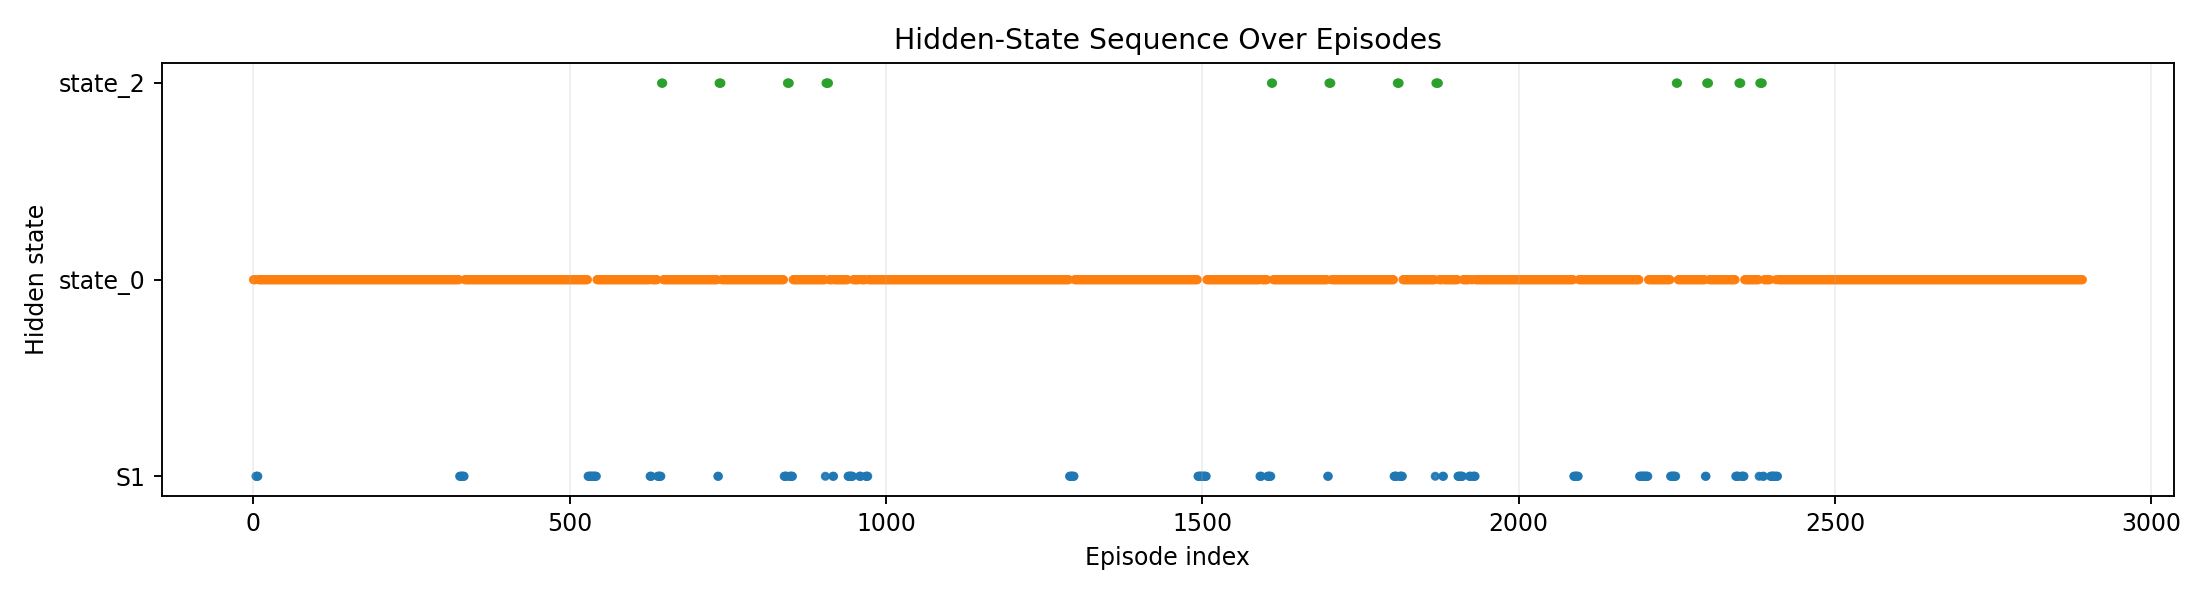

### state_probability_profile

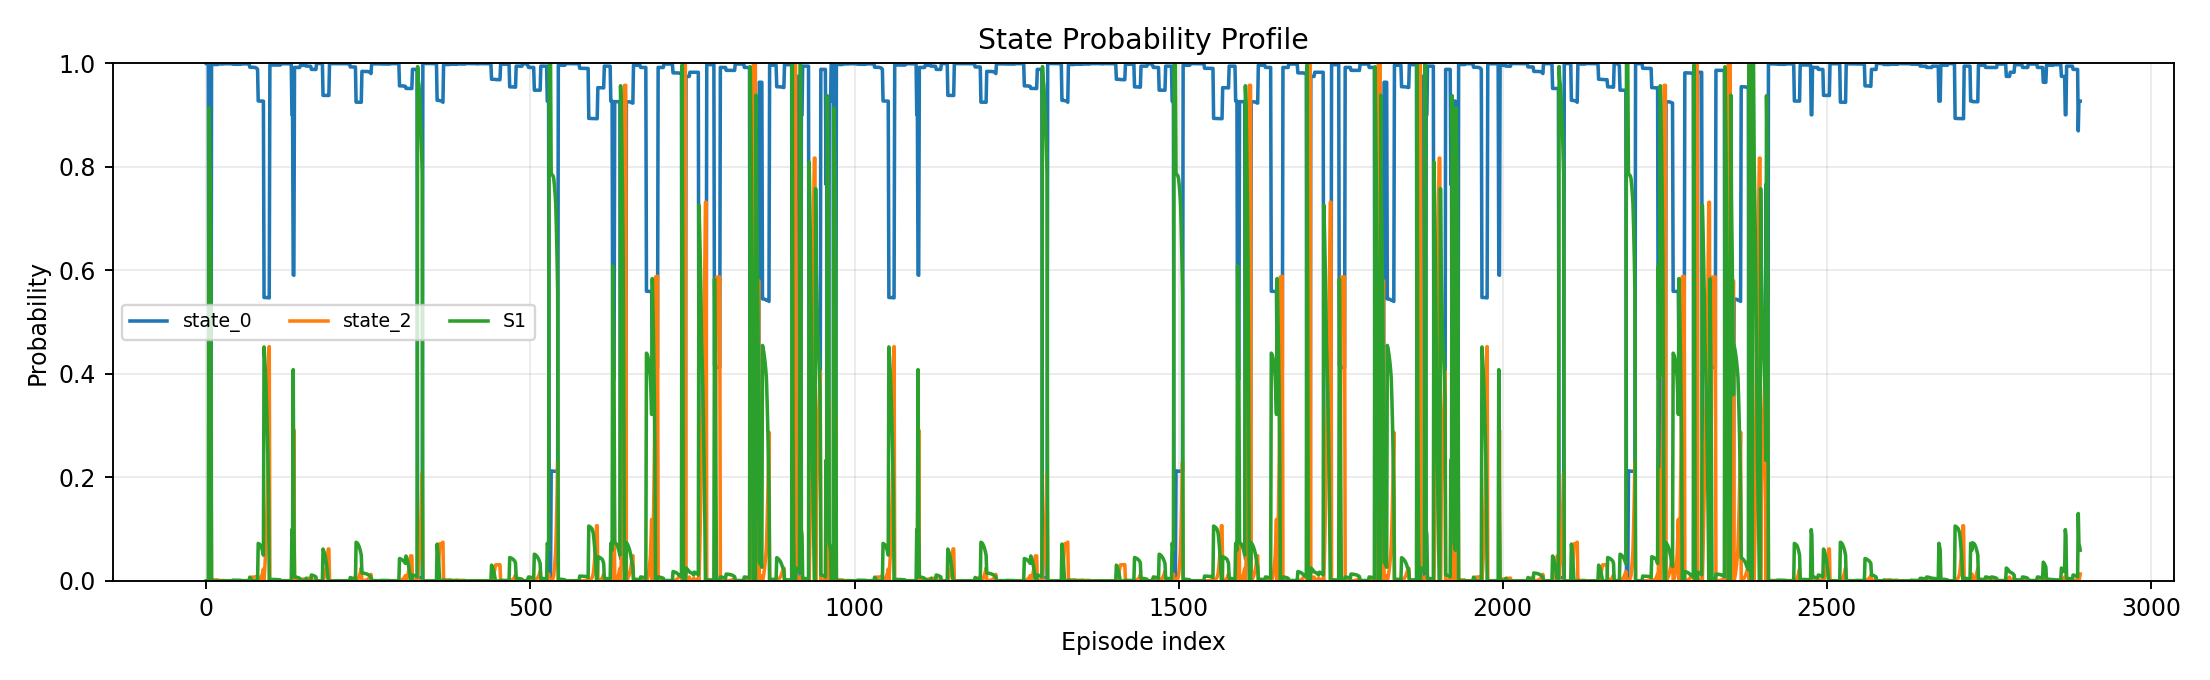

### transition_distribution

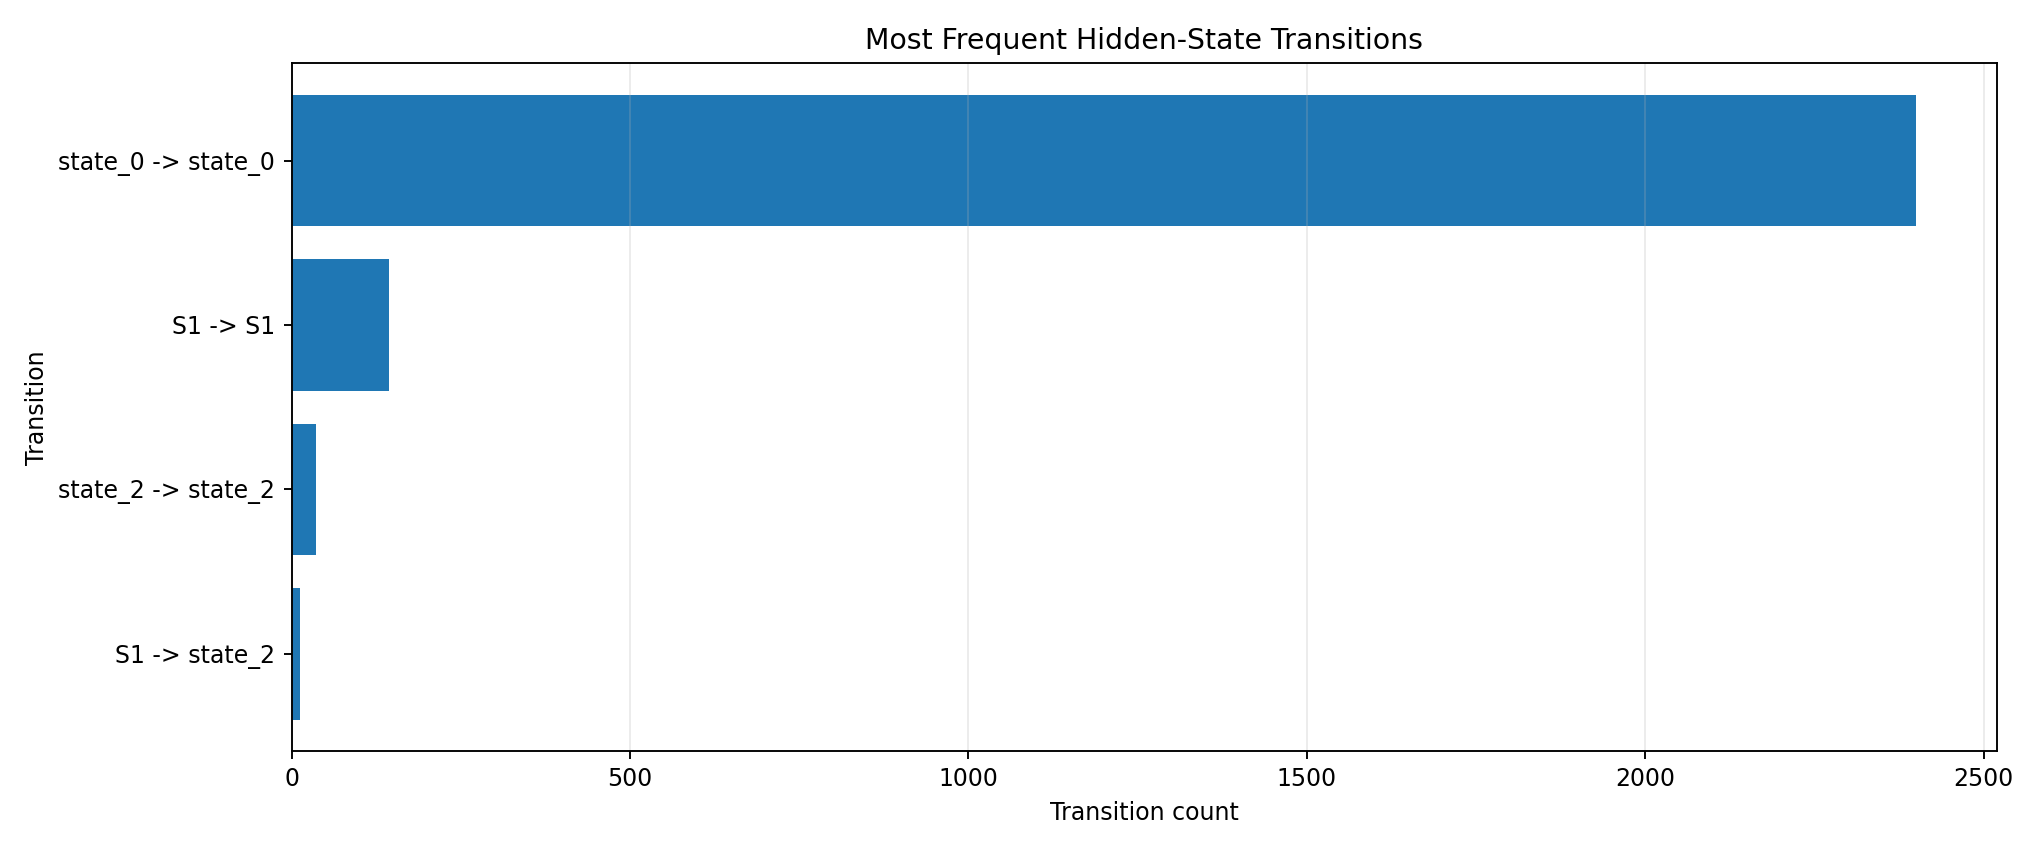

In [6]:
display(Markdown("## Plots"))
display_inverse_plots(artifacts.plot_paths)